## Gyroscope testing

In [1]:
%reload_ext autoreload
%autoreload 2

In [2]:
import numpy as np
import matplotlib.pyplot as plt
import pynwb
import pyarrow as pa
import pyarrow.parquet as pq
import pandas as pd
from spyglass.shijiegu.decodeHelpers import runSessionNames

[2026-03-06 09:31:07,889][INFO]: DataJoint 0.14.4 connected to shijiegu-alt@lmf-db.cin.ucsf.edu:3306


In [3]:
from spyglass.utils.nwb_helper_fn import get_nwb_copy_filename
from spyglass.shijiegu.gyroscope import (gyroscope_data_day,
    extract_gyro_data_in_interval, extract_position_data_in_interval,
    prepare_data_for_tracking,run_trodes_tracking,translate_time,translate_time_new, do_test_on_a_trial)
from spyglass.shijiegu.video import load_video_and_timestamps, make_mp4
from trodestrack.data.load_arthur_session import load_arthur_session, load_video_frame

from trodestrack.data.visualize_session import create_video_overlay
from trodestrack.data.visualize_filter_overlay_fast import create_filter_overlay_video_fast

In [10]:
# select trials
output_folder = "/stelmo/shijie/gyro/"


datasets = [#('julio20230731.nwb', "04_Seq2Session2", 15),
            #('julio20230808.nwb', '08_Seq2Session4', 27),
            #('molly20220417.nwb', "06_Seq2Session3", 20),
            #('molly20220419.nwb', "02_Seq2Session1", 52), #very interesting trial
            #('molly20220419.nwb', "02_Seq2Session1", 59), #very interesting trial
            ('molly20220419.nwb', "06_Seq2Session3", 50),
            #('klein20231107.nwb', "10_Rev2Session5", 79),
            # ('klein20231107.nwb', "10_Rev2Session5", 74),
           ]

In [11]:
parameters = {
    "process_noise_x_pos": 0.00002,
    "process_noise_y_pos": 0.00004,
    "process_noise_x_vel": 0.01,#2.0,
    "process_noise_y_vel": 0.1,#2.0,
    "process_noise_z_vel": 2e-4,#2.0,
    "process_noise_heading": 0.02,#0.1,#0.02,
    "process_noise_gyro_bias": 2e-6,#0.1,#2e-6,
    "process_noise_accel_x_bias": 2,#2e-4,
    "process_noise_accel_y_bias": 5,#2e-4,
    "process_noise_accel_z_bias": 2e-4,

    "measurement_noise_pos": 0.01**2, #0.01**2,#0.005**2,
    "measurement_noise_heading": 0.5**2, #0.1**2,#0.05**2,
    "damping_coeff": 6}

In [6]:
parameters = {
    "process_noise_x_pos": 0.0001,
    "process_noise_y_pos": 0.0004,
    "process_noise_x_vel": 0.001,#2.0,
    "process_noise_y_vel": 0.1,#2.0,
    "process_noise_z_vel": 2e-4,#2.0,
    "process_noise_heading": 0.02,#0.1,#0.02,
    "process_noise_gyro_bias": 2e-6,#0.1,#2e-6,
    "process_noise_accel_x_bias": 1.5,#2e-4,
    "process_noise_accel_y_bias": 4,#2e-4,
    "process_noise_accel_z_bias": 2e-4,
    "measurement_noise_pos": 0.01**2, #0.01**2,#0.005**2,
    "measurement_noise_heading": 0.5**2, #0.1**2,#0.05**2,
    "damping_coeff": 6}

In [6]:
for dataset in datasets:
    nwb_file_name, session_name, trial = dataset
    inferred_position_x, inferred_position_y, inferred_heading = do_test_on_a_trial(
                    nwb_file_name, session_name, trial,
                       make_sensor_video = False,
                       make_original_video = False,
                       make_filter_video = True,
                       use_reviewed = True,
                       parameters = parameters
                      )

NameError: name 'parameters' is not defined

### If we know a specific

In [12]:
for dataset in datasets:
    nwb_file_name, session_name, trial = dataset
    inferred_position_x, inferred_position_y, inferred_heading = do_test_on_a_trial(
                    nwb_file_name, session_name, trial,
                       make_sensor_video = False,
                       make_original_video = False,
                       make_filter_video = True,
                       use_table_result = True,
                       use_reviewed = True,
                       parameters = "big_acc_bias",
                      )

/home/shijiegu/anaconda3/envs/spyglass/lib/python3.10/site-packages/hdmf/spec/namespace.py:535: UserWarning: Ignoring cached namespace 'hdmf-common' version 1.5.1 because version 1.8.0 is already loaded.
  warn("Ignoring cached namespace '%s' version %s because version %s is already loaded."
/home/shijiegu/anaconda3/envs/spyglass/lib/python3.10/site-packages/hdmf/spec/namespace.py:535: UserWarning: Ignoring cached namespace 'core' version 2.4.0 because version 2.7.0 is already loaded.
  warn("Ignoring cached namespace '%s' version %s because version %s is already loaded."
/home/shijiegu/anaconda3/envs/spyglass/lib/python3.10/site-packages/hdmf/spec/namespace.py:535: UserWarning: Ignoring cached namespace 'hdmf-experimental' version 0.2.0 because version 0.5.0 is already loaded.
  warn("Ignoring cached namespace '%s' version %s because version %s is already loaded."
/home/shijiegu/anaconda3/envs/spyglass/lib/python3.10/site-packages/hdmf/spec/namespace.py:535: UserWarning: Ignoring cach

FAST FILTER OVERLAY VIDEO

Input: position_molly20220419.nwb_06_Seq2Session3_trial50_rawposition.mp4
  Resolution: 1456×1088
  Frame rate: 23.0 fps

Output: filter_molly20220419.nwb_06_Seq2Session3_50_default_parameter.mp4
  Start: 0.0s, Duration: 34.0s
  Output fps: 25.0

Generating 849 frames...
  Progress: 0/849 frames (0.0%)
Not adding IMU raw data plot
Not adding IMU raw data plot
Not adding IMU raw data plot
Not adding IMU raw data plot
Not adding IMU raw data plot
Not adding IMU raw data plot
Not adding IMU raw data plot
Not adding IMU raw data plot
Not adding IMU raw data plot
Not adding IMU raw data plot
Not adding IMU raw data plot
Not adding IMU raw data plot
Not adding IMU raw data plot
Not adding IMU raw data plot
Not adding IMU raw data plot
Not adding IMU raw data plot
Not adding IMU raw data plot
Not adding IMU raw data plot
Not adding IMU raw data plot
Not adding IMU raw data plot
Not adding IMU raw data plot
Not adding IMU raw data plot
Not adding IMU raw data plot
No

In [8]:
%debug

> /home/shijiegu/anaconda3/envs/spyglass/lib/python3.10/site-packages/trodestrack/data/visualize_filter_overlay_fast.py(314)create_filter_overlay_video_fast()
    312 
    313     # Extract filter states
--> 314     X_filter = np.array(filter_result.filtered_means)
    315     pos_filter = X_filter[:, :2]
    316     heading_filter = X_filter[:, 5]



ipdb>  u


> /home/shijiegu/Documents/spyglass/src/spyglass/shijiegu/gyroscope.py(674)do_test_on_a_trial()
    672 
    673     if make_filter_video:
--> 674         create_filter_overlay_video_fast(
    675             video_path = outputName + '_rawposition.mp4',
    676             data = packed_data,



ipdb>  result


{'packed_data': SessionData(t_imu=array([0.00000000e+00, 1.43313408e-03, 1.14321709e-02, ...,
       4.93917978e+01, 4.94017968e+01, 4.94117961e+01]), t_cam=array([4.12495136e-02, 8.39586258e-02, 1.26668215e-01, ...,
       4.93228137e+01, 4.93655231e+01, 4.94082327e+01]), U_imu=array([[-0.64730775, -2.8809586 ,  4.436293  ],
       [-0.9528625 , -2.8809586 ,  4.436293  ],
       [-1.3968219 , -1.3555341 ,  6.151947  ],
       ...,
       [ 0.5067738 , -4.7724843 ,  5.420341  ],
       [ 0.46951103, -4.7880383 ,  5.651847  ],
       [ 0.41414917, -4.0037904 ,  4.75394   ]], dtype=float32), Z_cam_led1=array([[2.085 , 2.2975],
       [2.0875, 2.2975],
       [2.0875, 2.295 ],
       ...,
       [1.2775, 0.9275],
       [1.2775, 0.925 ],
       [1.275 , 0.93  ]]), Z_cam_led2=array([[2.0825, 2.355 ],
       [2.095 , 2.355 ],
       [2.105 , 2.3575],
       ...,
       [1.2325, 0.8825],
       [1.2325, 0.8825],
       [1.23  , 0.8825]]), mask_cam=array([ True,  True,  True, ...,  True,  Tru

ipdb>  result.keys()


dict_keys(['packed_data', 'result'])


ipdb>  exit


In [86]:
#arrow_heading

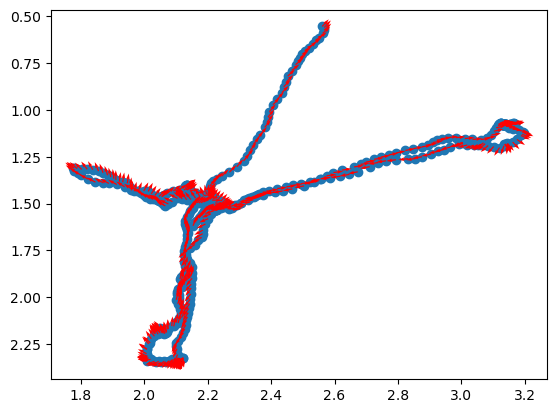

In [93]:
plt.scatter(inferred_position_x, inferred_position_y)


arrow_length = 20
arrow_heading = inferred_heading + np.pi
dx = arrow_length * np.cos(arrow_heading)
dy = arrow_length * np.sin(arrow_heading)
plt.gca().quiver(inferred_position_x,inferred_position_y, dx, dy, linewidth = 5, color = 'red', angles = 'xy')

plt.gca().invert_yaxis() 

In [7]:
%debug

> /home/shijiegu/anaconda3/envs/spyglass/lib/python3.10/site-packages/trodestrack/models/process_noise.py(92)build_Q_rate()
     90     for idx in layout.bias_gyro_idx:
     91         diag = diag.at[idx].set(config.process_noise_gyro_bias)
---> 92     assert 1 == 0
     93     # Accel bias noise
     94     for idx in layout.bias_accel_idx:



ipdb>  layout


StateLayout(n=10, pos_idx=(0, 1), vel_idx=(2, 3, 4), heading_idx=5, bias_gyro_idx=(6,), bias_accel_idx=(7, 8, 9))


ipdb>  exit


# end here

### try writing result to nwb

In [10]:
from spyglass.shijiegu.gyroscope import load_tracking_result
from spyglass.shijiegu.Analysis_SGU import Imu, TrialChoice

In [11]:
TrialChoice()

nwb_file_name name of the NWB file,epoch the session epoch for this task and apparatus(1 based),"epoch_name session name, get from IntervalList","choice_reward pandas dataframe, choice"
eliot20221016_.nwb,2,02_Seq2Session1,=BLOB=
eliot20221016_.nwb,4,04_Seq2Session2,=BLOB=
eliot20221016_.nwb,6,06_Seq2Session3,=BLOB=
eliot20221016_.nwb,8,08_Seq2Session4,=BLOB=
eliot20221017_.nwb,2,02_Seq2Session1,=BLOB=
eliot20221017_.nwb,4,04_Seq2Session2,=BLOB=
eliot20221017_.nwb,6,06_Seq2Session3,=BLOB=
eliot20221017_.nwb,8,08_Seq2Session4,=BLOB=
eliot20221018_.nwb,2,02_Seq2Session1,=BLOB=
eliot20221018_.nwb,4,04_Seq2Session2,=BLOB=


In [7]:
Imu()

nwb_file_name name of the NWB file,epoch the session epoch for this task and apparatus(1 based),trial trial,parameter parameter name,pos_info tracking


In [18]:
for dataset in datasets:
    nwb_file_name, session_name, trial = dataset
    pos_info = load_tracking_result(output_folder, nwb_file_name, session_name, trial)
    key = {"nwb_file_name": get_nwb_copy_filename(nwb_file_name),
           "epoch": str(session_name[:2]),
           "trial": trial,
           "parameter": "default",
           "pos_info": pos_info.to_dict()
          }
    Imu().insert1(key)

In [21]:
key = {"nwb_file_name": get_nwb_copy_filename(nwb_file_name),
           "epoch": str(session_name[:2]),
           "trial": trial,
           "parameter": "default",
          }
Imu().fetch1_dataframe(key)

,head_position_x,head_position_y,head_orientation
1.699400e+09,213.375000,232.125000,1.607815
1.699400e+09,213.005203,232.366089,1.650386
1.699400e+09,212.514252,232.605240,1.702333
1.699400e+09,212.139771,232.606552,1.748713
1.699400e+09,212.141754,232.608978,1.760684
...,...,...,...
1.699400e+09,123.227356,93.771599,3.946186
1.699400e+09,122.855591,94.518364,3.976502
1.699400e+09,122.484169,95.391739,3.925869
1.699400e+09,122.483681,96.147560,3.889410


In [ ]:
# for the day, load trodes sample count and system time (in unix seconds)
nwb_copy_file_name = get_nwb_copy_filename(nwb_file_name)
nwb_file_abs_path = (Nwbfile & {'nwb_file_name':nwb_copy_file_name}).fetch1('nwb_file_abs_path')
io = pynwb.NWBHDF5IO(nwb_file_abs_path,'r')
nwbf = io.read()
sample_count=np.array(nwbf.processing['sample_count'].data_interfaces['sample_count'].data)
time_seconds=np.array(nwbf.processing['sample_count'].data_interfaces['sample_count'].timestamps)

In [ ]:
trodes_sample_time = data_day['04_Seq2Session2']['timestamps']['data'].astype("int64")


In [ ]:
translated_time = translate_time(trodes_sample_time,sample_count,time_seconds)

In [ ]:
trodes_sample_time[0]

In [ ]:
trodes_sample_time[-1]

In [ ]:
sample_count[0]

In [ ]:
sample_count[-1]

In [ ]:
translated_time[-1]

In [ ]:
translated_time[0]

In [ ]:
np.intersect1d([1,2,1,5],[1,2,3,4,1,2,5],return_indices=True)

In [ ]:
plt.scatter(sample_count[::10],time_seconds[::10])

In [ ]:
sample = [1,2,1,2]
sample_all = [1,2,3,4,1,2]
np.argwhere(np.isin(sample_all, sample)).ravel()

In [ ]:
plt.plot(time_seconds[::10])

In [ ]:
plt.plot(time_seconds)

In [ ]:
notnan_ind=np.argwhere(~np.isnan(trodes_sample_time)).ravel()
xy,ind1,ind2=np.intersect1d(trodes_sample_time[notnan_ind],sample_count,return_indices=True)
#assert np.sum(~nan_ind)==len(ind2)
translated_sys_time=np.zeros_like(trodes_sample_time)+np.nan
translated_sys_time[notnan_ind[ind1]]=time_seconds[ind2]

In [ ]:
plt.plot(data_day['04_Seq2Session2']['timestamps']['data'])

In [ ]:
plt.plot(data_day['06_Seq2Session3']['timestamps']['unix'])

In [ ]:
data_day['04_Seq2Session2']['timestamps']['unix'][0]

In [ ]:
data_day['04_Seq2Session2']['timestamps']['unix'][-1]

### 2. Basic testing

In [ ]:
from spyglass.shijiegu.decodeHelpers import runSessionNames
from spyglass.common.common_position import IntervalPositionInfo
from spyglass.shijiegu.Analysis_SGU import ChangeofMindTheta
from spyglass.shijiegu.helpers import mergeIntervals,interpolate_to_new_time

In [ ]:
# session information
session_interval, position_interval = runSessionNames(nwb_copy_file_name)
session_name = session_interval[0]
pos_name = position_interval[0]

In [ ]:
# position
key = {"nwb_file_name": nwb_copy_file_name,"interval_list_name":pos_name}
position_info = (IntervalPositionInfo() & {'nwb_file_name': nwb_copy_file_name,
                'interval_list_name': pos_name,
                "position_info_param_name": "default",
                                          }).fetch1_dataframe()

In [ ]:
# trials of interest
q = {"nwb_file_name": nwb_copy_file_name,
     "epoch":int(session_name[:2]),
     "proportion":str(0.1),
     "delta_t_minus":5,
     "delta_t_plus":5}

log_df = ChangeofMindTheta().fetch1_dataframe(q)

change_of_mind_trials = log_df[log_df.change_of_mind].index
print(f"Change of mind trials are: {change_of_mind_trials}")

### subset of trials

In [ ]:
trial1 = 35
trial2 = 37
(t0,t1) = (log_df.loc[trial1].timestamp_H, 
           log_df.loc[trial2].timestamp_O)
extracted_data = extract_gyro_data_in_interval(data_day[session_name], (t0, t1))
gyro_time_trial = extracted_data["timestamps"]

In [ ]:
position_info_upsample = interpolate_to_new_time(position_info, gyro_time_trial)
position_info_t = np.array( position_info_upsample.loc[position_info_upsample.head_speed <= 4].index )
low_speed_t = np.isin(gyro_time_trial, position_info_t)

#### (1) Scale as if all chanels are accelerameter

In [ ]:
SCALE_FACTOR = 0.000061 * 9.80665 # SCALE_FACTOR for acceleration
fig, axes = plt.subplots(6,1,figsize = (10,12))

t = gyro_time_trial

ind = 0
for data_name in ["AccelX", "AccelY", "AccelZ", "GyroX", "GyroY", "GyroZ"]:
    data_X = extracted_data[data_name].astype("float64")
    axes[ind].plot(t, data_X * SCALE_FACTOR, label = data_name) 
    axes[ind].scatter(t[low_speed_t], data_X[low_speed_t] * SCALE_FACTOR,
                    marker = '*', color = 'r', label = "immobility", s = 3)
    
    axes[ind].set_title(data_name)
    axes[ind].axhline(-9.8)
    ind += 1

#### (2) Scale as if all chanels are gyroscope

In [ ]:
SCALE_FACTOR = 0.061

fig, axes = plt.subplots(6,1,figsize = (10,12))

t = gyro_time_trial

ind = 0
for data_name in ["AccelX", "AccelY", "AccelZ", "GyroX", "GyroY", "GyroZ"]:
    data_X = extracted_data[data_name].astype("float64")
    axes[ind].plot(t, data_X * SCALE_FACTOR, label = data_name) 
    axes[ind].scatter(t[low_speed_t], data_X[low_speed_t] * SCALE_FACTOR,
                    marker = '*', color = 'r', label = "immobility", s = 3)
    
    axes[ind].set_title(data_name)
    axes[ind].axhline(2000, color = 'C1')
    axes[ind].axhline(-2000, color = 'C1')
    ind += 1

### run Trodes tracking

In [ ]:
trial1 = 35
trial2 = 37
(t0,t1) = (log_df.loc[trial1].timestamp_H, 
           log_df.loc[trial2].timestamp_O)
extracted_imu_data = extract_gyro_data_in_interval(data_day[session_name], (t0, t1))
extracted_pos_data, table_original, meters_per_pixel = extract_position_data_in_interval(
    nwb_copy_file_name, (t0, t1), pos_name)

imu_path = f'/cumulus/shijie/gyro/imu_{nwb_file_name}_{session_name}_trial{trial1}.parquet'  # the path to write imu data to
pos_path = f'/cumulus/shijie/gyro/position_{nwb_file_name}_{session_name}_trial{trial1}.parquet' # the path to write pos data to

packed_data = prepare_data_for_tracking(
    extracted_imu_data, extracted_pos_data, imu_path, pos_path, meters_per_pixel)


In [ ]:
inferred_position_x, inferred_position_y, inferred_heading, result = run_trodes_tracking(packed_data)

In [ ]:
fig, axes = plt.subplots(2,2, figsize = (12,6))
axes[0,0].set_title("filtered result")
axes[0,0].scatter(inferred_position_x, inferred_position_y,s = 1)

axes[0,1].plot(packed_data.t_cam, inferred_heading)
axes[0,1].set_title("Estimated heading (radius)")

axes[1,0].scatter(packed_data.Z_cam_led1[:,0], packed_data.Z_cam_led1[:,1],s = 1)
axes[1,0].set_title("input")

axes[1,1].plot(packed_data.t_imu, packed_data.U_imu[:,0])
axes[1,1].set_title("Gyro z")

### Make video

In [8]:
from trodestrack.data.visualize_session import create_video_overlay
from trodestrack.data.visualize_filter_overlay_fast import create_filter_overlay_video_fast

from trodestrack.data.load_arthur_session import load_video_frame
from spyglass.shijiegu.video import load_video_and_timestamps, make_mp4

In [ ]:
cap, timestamps, meters_per_pixel = load_video_and_timestamps(nwb_copy_file_name, session_name)

In [ ]:
#outputName = f'/cumulus/shijie/gyro/position_{nwb_file_name}_{session_name}_trial{trialID}'
outputName = f'position_{nwb_file_name}_{session_name}_trial{trial1}'
make_mp4(cap, timestamps, t0, t1, outputName)

create_video_overlay(
    video_path = outputName + '_rawposition.mp4',
    data = packed_data,
    imu_mode = "2d",
    position_df = extracted_pos_data.to_pandas(),
    output_path = "overlay_3DIMU.mp4",
    start_time=0.0,
    duration=t1-t0,
    fps=25.0,
    gyro_ylim=(-200, 200),    # deg/s
    accel_ylim=(-15, 15)      # m/s²
)

create_filter_overlay_video_fast(
    video_path = outputName + '_rawposition.mp4',
    data = packed_data,
    filter_result = result,
    t_filter = packed_data.t_cam,
    position_df = extracted_pos_data.to_pandas(),
    output_path = f"filter_{nwb_file_name}_{session_name}_gyrobias{np.round(process_noise_gyro_bias,4)}_posprocessnoise{np.round(process_noise_pos,4)}_headingprocessnoise{np.round(process_noise_heading,4)}_posnoise{np.round(measurement_noise_pos,4)}_headnoise{np.round(measurement_noise_heading,4)}.mp4",
    start_time=0.0,
    duration=t1-t0,
    fps=25.0
)

In [ ]:
process_noise_heading = 0.02 #0.1
process_noise_pos =  0.02 #0.005 #0.02
process_noise_gyro_bias = 2e-6 #0.9
measurement_noise_pos = 0.005**2 #0.4**2
measurement_noise_heading = 0.05**2 #0.9**2

create_filter_overlay_video_fast(
    video_path = outputName + '_rawposition.mp4',
    data = packed_data,
    filter_result = result,
    t_filter = packed_data.t_cam,
    position_df = extracted_pos_data.to_pandas(),
    output_path = f"filter_{nwb_file_name}_{session_name}_gyrobias{np.round(process_noise_gyro_bias,4)}_posprocessnoise{np.round(process_noise_pos,4)}_headingprocessnoise{np.round(process_noise_heading,4)}_posnoise{np.round(measurement_noise_pos,4)}_headnoise{np.round(measurement_noise_heading,4)}.mp4",
    start_time=0.0,
    duration=t1-t0,
    fps=25.0
)